In [2]:
import warnings
from typing import List, Literal, Optional, Tuple

import moscot as mt
import moscot.plotting as mtp
#import ot
import tqdm
from moscot.problems.time import LineageProblem, TemporalProblem

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances

import matplotlib.pyplot as plt

import scanpy as sc
from anndata import AnnData

warnings.simplefilter("ignore", UserWarning)

In [38]:
sc.settings.figdir = "../../descriptive_results/rna_trajecotry/plot/"

In [3]:
def compute_w2(
    p_1: np.ndarray,
    p_2: np.ndarray,
    cost: np.ndarray,
    metric_type: Literal["descendant", "ancestor"],
    scale_by_marginal: bool = True,
) -> List[float]:
    errors = []

    # transpose for ancestors
    if metric_type == "ancestor":
        p_1 = p_1.T
        p_2 = p_2.T

    # iterate over all cells
    for i in tqdm.tqdm(range(p_1.shape[0])):
        # normalize to get distributions
        marginal = p_1[i].sum()
        dist_1 = p_1[i] / marginal
        dist_2 = p_2[i] / p_2[i].sum()

        # compute the EMD distance between the ground-truth and the prediction
        error, log = ot.emd2(
            dist_1.astype(float), dist_2.astype(float), cost.astype(float), log=True
        )

        # append the EMD (potentially scaled by the marignal)
        if log["warning"] is None:
            if scale_by_marginal:
                errors.append(marginal * error)
            else:
                errors.append(error)
        else:
            errors.append(np.nan)

    return errors

In [4]:
def get_cost(
    adata: AnnData,
    early_tp: float = 8,
    late_tp: float = 12,
    time_key: str = "time",
    rep: str = "X_pca",
    n_dim: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    # retrieve cost matrices
    embedding = np.asarray(adata.obsm[rep], dtype=float)

    # make sure we have enough dimensions
    if n_dim is None:
        n_dim = embedding.shape[1]
    elif embedding.shape[1] < n_dim:
        raise ValueError(f"You only have {embedding.shape[1]} dimensions in {rep}.")
    embedding = embedding[:, :n_dim]

    # restrict to early and late cells
    mask_early, mask_late = (
        adata.obs[time_key] == early_tp,
        adata.obs[time_key] == late_tp,
    )
    embedding_early, embedding_late = embedding[mask_early], embedding[mask_late]

    # compute the corresponding distance matrices
    cost_early = euclidean_distances(embedding_early, squared=True)
    cost_late = euclidean_distances(embedding_late, squared=True)

    return cost_early, cost_late

In [5]:
def compute_errors(
    adata: AnnData,
    p_1: np.ndarray,
    p_2: np.ndarray,
    early_tp: float = 8,
    late_tp: float = 12,
    time_key: str = "time",
    rep: str = "X_pca",
    n_dim: Optional[int] = None,
    scale_by_marginal: bool = True,
) -> Tuple[List[float], List[float]]:
    # check that the shapes match
    assert p_1.shape == p_2.shape

    # retrieve early and late cost matrices
    cost_early, cost_late = get_cost(
        adata=adata,
        early_tp=early_tp,
        late_tp=late_tp,
        time_key=time_key,
        rep=rep,
        n_dim=n_dim,
    )

    # compute the ancestor errors
    ancestor_errors = compute_w2(
        p_1=p_1,
        p_2=p_2,
        cost=cost_early,
        metric_type="ancestor",
        scale_by_marginal=scale_by_marginal,
    )

    # compute the descendant errors
    descendant_errors = compute_w2(
        p_1=p_1,
        p_2=p_2,
        cost=cost_late,
        metric_type="descendant",
        scale_by_marginal=scale_by_marginal,
    )

    return ancestor_errors, descendant_errors

In [7]:
scvi = sc.read("../../../2024.4_scATAC//processed_data/framework/4.29_scvi.h5ad")

In [8]:
sc.pp.normalize_total(scvi)
sc.pp.log1p(scvi)

In [9]:
anno = pd.read_csv("../../../2024.4_scATAC//processed_data/cluster/rna_annotation_scvi_mod.csv",index_col=0)

In [10]:
scvi.obs[anno.columns] = anno

In [11]:
scvi.obs["time"]=np.nan
scvi.obs["time"][scvi.obs["group"]=="E125"]=12.5
scvi.obs["time"][scvi.obs["group"]=="E145"]=14.5

/tmp/ipykernel_364712/2377070010.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  scvi.obs["time"][scvi.obs["group"]=="E125"]=12.5
/tmp/ipykernel_364712/2377070010.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

In [12]:
tp = TemporalProblem(scvi)
tp = tp.prepare(time_key="time", joint_attr="X_scVI")
tp = tp.solve(epsilon=1e-3, tau_a=0.99)

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(12998, 6406)].                                 


In [14]:
scvi.obs["level1_anno"]=scvi.obs["level1_anno"].astype("category")

In [15]:
cell_transition = tp.cell_transition(
    source=12.5,
    target=14.5,
    source_groups={"level1_anno": ['stem cells','Transit','K5(-)','Mature K5(-) ','Shh(+)','K14(-)','K6+ cells']},
    target_groups={"level1_anno": ['Transit','K5(-)','Mature K5(-) ','Shh(+)','K6+ cells']},
    forward=True,
    key_added="tp_transitions",
)

/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/moscot/base/problems/_mixins.py:506: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_dist = df[df[annotation_key].isin(annotations_2)].groupby(annotation_key).sum(numeric_only=True)
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/moscot/base/problems/_mixins.py:506: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_dist = df[df[annotation_key].isin(annotations_2)].groupby(annotation_key).sum(numeric_only=True)
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/moscot/base/problems/_mixins.py:506: FutureWarni

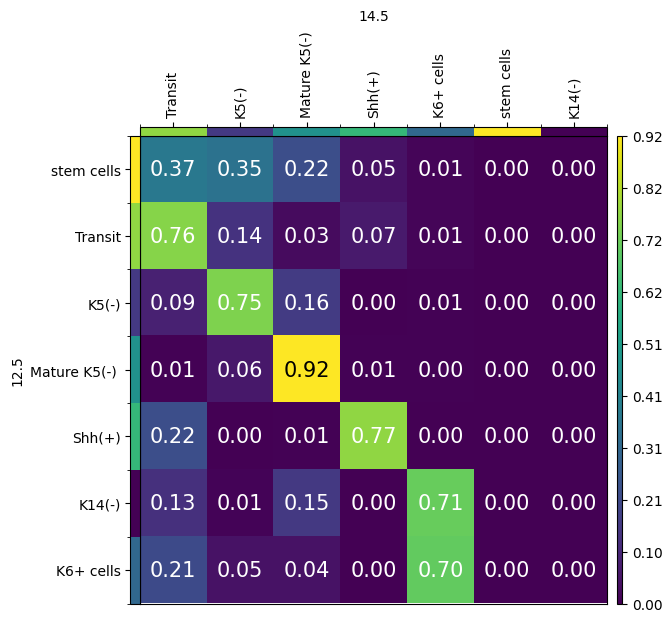

In [39]:
mtp.cell_transition(tp, fontsize=15, figsize=(5, 5), key="tp_transitions",save="../../descriptive_results/rna_trajecotry/plot/moscot_hm.pdf")

In [47]:
cell_transition.to_csv("../../descriptive_results/rna_trajecotry/moscot_transition.csv")

In [48]:
cell_transition

,Transit,K5(-),Mature K5(-),Shh(+),K6+ cells,stem cells,K14(-)
stem cells,0.369848,0.349779,0.221790,4.691470e-02,0.011668,0,0
Transit,0.757051,0.137068,0.026703,6.784297e-02,0.011335,0,0
K5(-),0.086197,0.747755,0.159472,4.684797e-04,0.006108,0,0
Mature K5(-),0.006677,0.059038,0.924880,5.248908e-03,0.004156,0,0
Shh(+),0.221353,0.002763,0.005506,7.703775e-01,0.000000,0,0
K14(-),0.129112,0.008622,0.151912,1.244207e-03,0.709110,0,0
K6+ cells,0.206645,0.046438,0.043420,7.460666e-15,0.703497,0,0


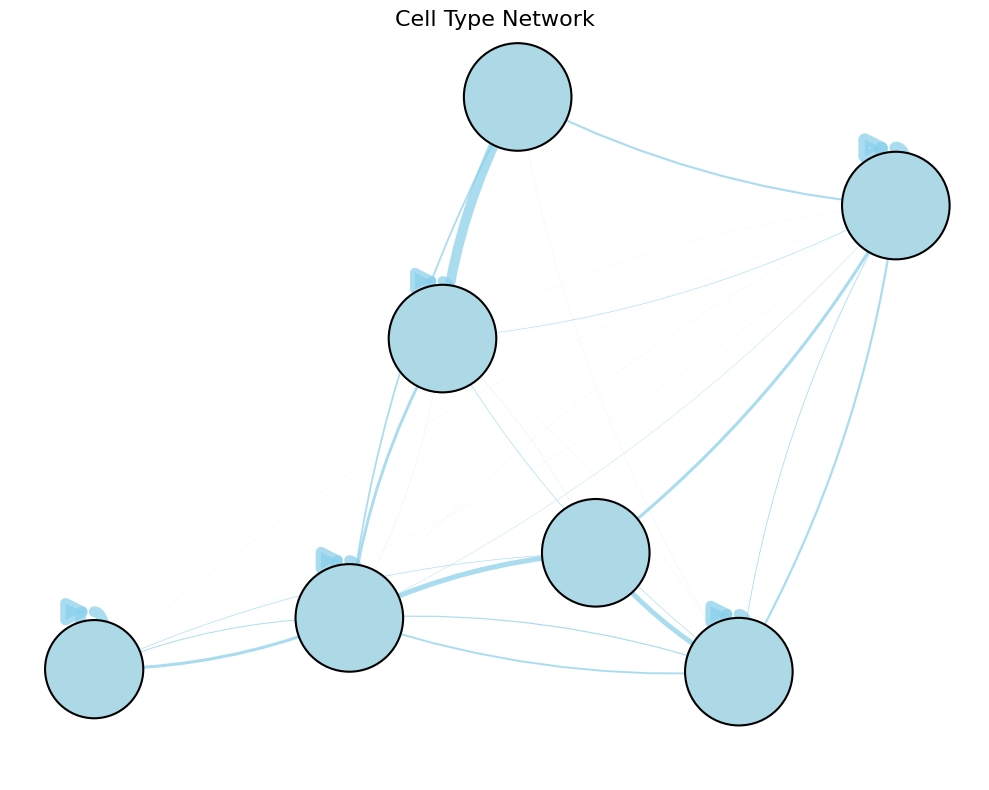

In [46]:
# Create a directed graph
G = nx.from_pandas_adjacency(df, create_using=nx.DiGraph)

# Set node colors and sizes
node_color = 'lightblue'  # Use a single color for all nodes
node_size = [1000 * (G.out_degree(node) + 1) for node in G.nodes()]

# Set edge width based on weight
edge_width = [10 * G[u][v]['weight'] for u, v in G.edges()]

# Draw the network
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)  # Positions for all nodes

# Draw nodes with borders
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size, edgecolors='black', linewidths=1.5)

# Draw directed edges with arrows
nx.draw_networkx_edges(G, pos, width=edge_width, edge_color='skyblue', alpha=0.7, arrows=True, arrowstyle='-|>', arrowsize=30, connectionstyle='arc3,rad=0.1', min_source_margin=15, min_target_margin=15)

plt.title("Cell Type Network", fontsize=16)
plt.axis('off')  # Hide the axes
plt.tight_layout()
plt.show()  # This will display the plot

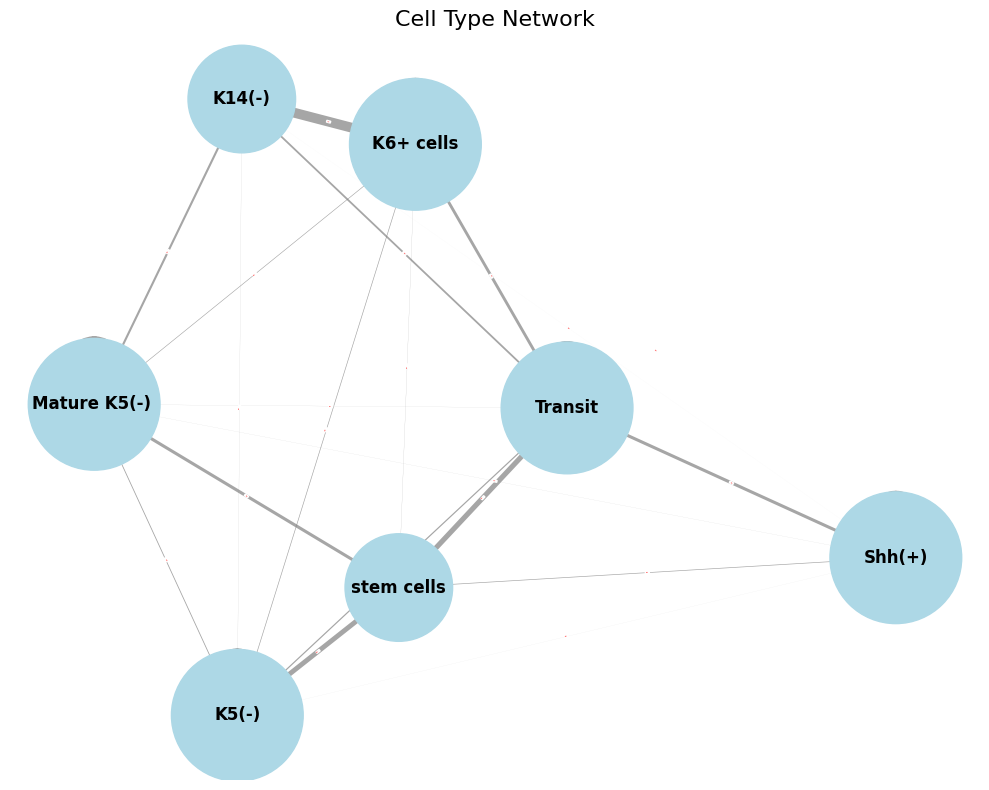

In [34]:
df = cell_transition
# Add missing columns with zero values to make the DataFrame square
for col in df.index:
    if col not in df.columns:
        df[col] = 0

# Reorder columns to match the index
df = df[df.index]

# Create a graph
G = nx.from_pandas_adjacency(df)

# Set node colors and sizes based on degree (number of connections)
node_color = ['lightblue' if degree < 3 else 'lightblue' for node, degree in G.degree()]
node_size = [1000 * (G.degree(node) + 1) for node in G.nodes()]

# Set edge width based on weight
edge_width = [10 * G[u][v]['weight'] for u, v in G.edges()]

# Draw the network
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)  # Positions for all nodes
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
nx.draw_networkx_edges(G, pos, width=edge_width, edge_color='gray', alpha=0.7)

# Draw edge labels with weights
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=0, font_color='red')

plt.title("Cell Type Network", fontsize=16)
plt.axis('off')  # Hide the axes
plt.tight_layout()
plt.show()  # This will display the plot

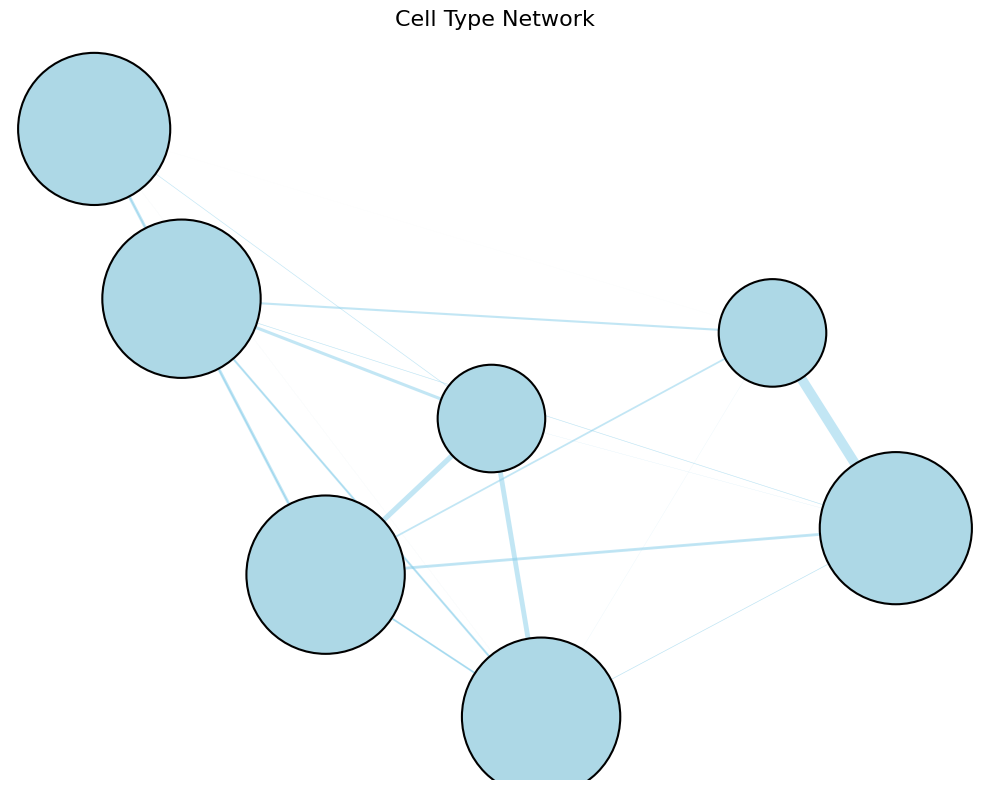

In [41]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Assuming cell_transition is your DataFrame
df = cell_transition

# Add missing columns with zero values to make the DataFrame square
for col in df.index:
    if col not in df.columns:
        df[col] = 0

# Reorder columns to match the index
df = df[df.index]

# Create a directed graph
G = nx.from_pandas_adjacency(df, create_using=nx.DiGraph)

# Set node colors and sizes
node_color = 'lightblue'  # Use a single color for all nodes
node_size = [1000 * (G.degree(node) + 1) for node in G.nodes()]

# Set edge width based on weight
edge_width = [10 * G[u][v]['weight'] for u, v in G.edges()]

# Draw the network
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)  # Positions for all nodes

# Draw nodes with borders
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size, edgecolors='black', linewidths=1.5)

# Draw directed edges with arrows
nx.draw_networkx_edges(G, pos, width=edge_width, edge_color='skyblue', alpha=0.5, arrows=True, arrowstyle='-|>', arrowsize=15)

plt.title("Cell Type Network", fontsize=16)
plt.axis('off')  # Hide the axes
plt.tight_layout()
plt.show()  # This will display the plot

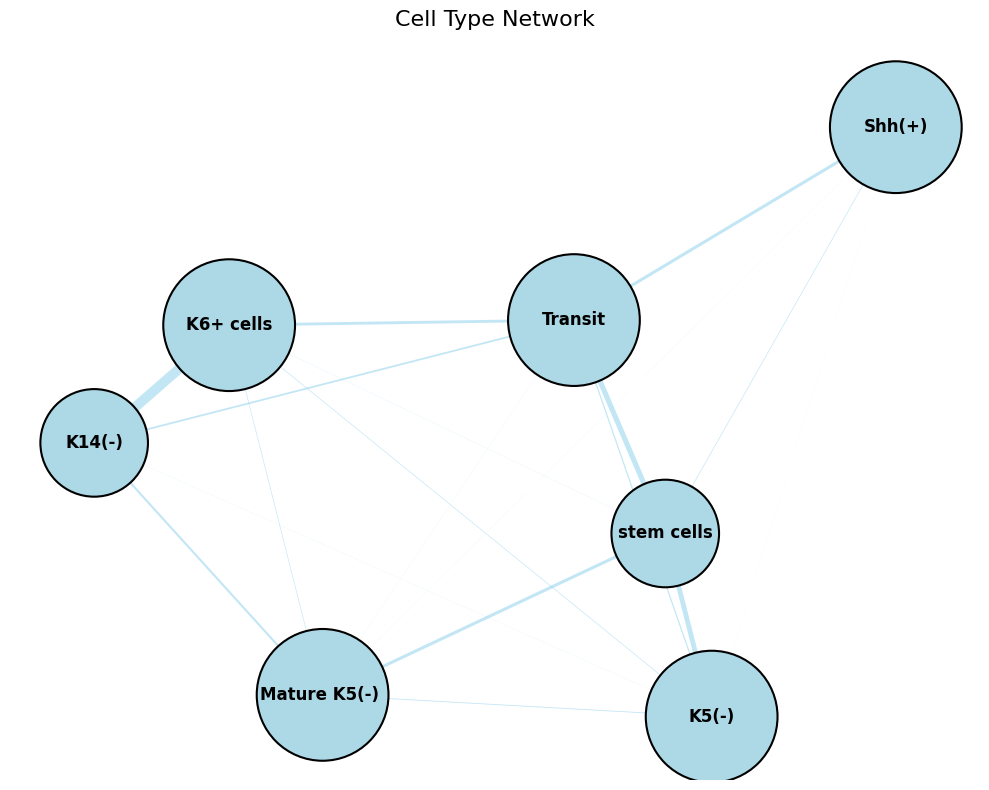

In [37]:
# Add missing columns with zero values to make the DataFrame square
for col in df.index:
    if col not in df.columns:
        df[col] = 0

# Reorder columns to match the index
df = df[df.index]

# Create a graph
G = nx.from_pandas_adjacency(df)

# Set node colors and sizes
node_color = 'lightblue'  # Use a single color for all nodes
node_size = [1000 * (G.degree(node) + 1) for node in G.nodes()]

# Set edge width based on weight
edge_width = [10 * G[u][v]['weight'] for u, v in G.edges()]

# Draw the network
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)  # Positions for all nodes

# Draw nodes with borders
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size, edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
# Draw edges with a gradient color
nx.draw_networkx_edges(G, pos, width=edge_width, edge_color='skyblue', alpha=0.5)

# Optionally, draw edge labels with weights (commented out as per your request)
# edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_color='red')

plt.title("Cell Type Network", fontsize=16)
plt.axis('off')  # Hide the axes
plt.tight_layout()
plt.savefig("../../descriptive_results/rna_trajecotry/plot/moscot_network.pdf")
plt.show()  # This will display the plot

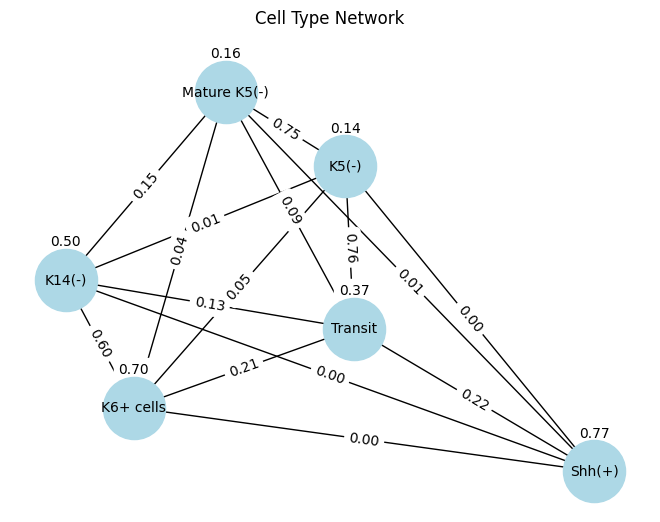

In [25]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Updated sample data including K14(-)
data = {
    "": ["Transit", "K5(-)", "Mature K5(-)", "Shh(+)", "K14(-)", "K6+ cells"],
    "Transit": [0.369848, 0.757051, 0.086197, 0.221353, 0.129112, 0.206645],
    "K5(-)": [0.349779, 0.137068, 0.747755, 0.002763, 0.008622, 0.046438],
    "Mature K5(-)": [0.221790, 0.026703, 0.159472, 0.005506, 0.151912, 0.043420],
    "Shh(+)": [4.691470e-02, 6.784297e-02, 4.684797e-04, 7.703775e-01, 1.244207e-03, 7.460666e-15],
    "K14(-)": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],  # Adjust values as needed
    "K6+ cells": [0.011668, 0.011335, 0.006108, 0.004156, 0.709110, 0.703497]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Set the first column as the index
df.set_index("", inplace=True)

# Create a graph
G = nx.from_pandas_adjacency(df)

# Draw the network
pos = nx.spring_layout(G)  # Positions for all nodes
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10)

# Draw edge labels
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Cell Type Network")
plt.show()  # This will display the plot

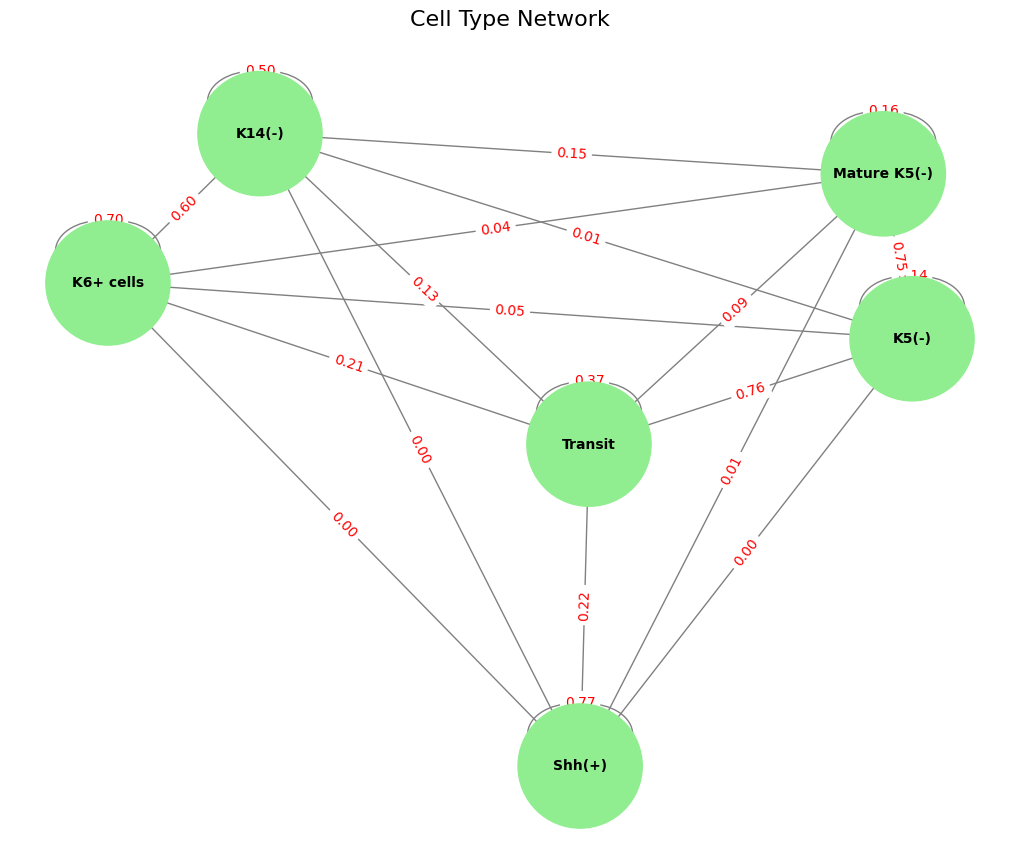

In [26]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Sample data including K14(-)
data = {
    "": ["Transit", "K5(-)", "Mature K5(-)", "Shh(+)", "K14(-)", "K6+ cells"],
    "Transit": [0.369848, 0.757051, 0.086197, 0.221353, 0.129112, 0.206645],
    "K5(-)": [0.349779, 0.137068, 0.747755, 0.002763, 0.008622, 0.046438],
    "Mature K5(-)": [0.221790, 0.026703, 0.159472, 0.005506, 0.151912, 0.043420],
    "Shh(+)": [0.046914, 0.067843, 0.000468, 0.770377, 0.001244, 0.000000],
    "K14(-)": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],  # Adjust as needed
    "K6+ cells": [0.011668, 0.011335, 0.006108, 0.004156, 0.709110, 0.703497]
}

# Convert to DataFrame
df = pd.DataFrame(data)
df.set_index("", inplace=True)

# Create a graph
G = nx.from_pandas_adjacency(df)

# Set node colors and sizes based on degree (number of connections)
node_color = ['lightblue' if degree < 3 else 'lightgreen' for node, degree in G.degree()]
node_size = [1000 * (G.degree(node) + 1) for node in G.nodes()]

# Draw the network
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)  # Positions for all nodes
nx.draw(G, pos, with_labels=True, node_color=node_color, node_size=node_size, font_size=10, font_weight='bold', edge_color='gray')

# Draw edge labels with weights
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Cell Type Network", fontsize=16)
plt.axis('off')  # Hide the axes
plt.tight_layout()
plt.show()  # This will display the plot


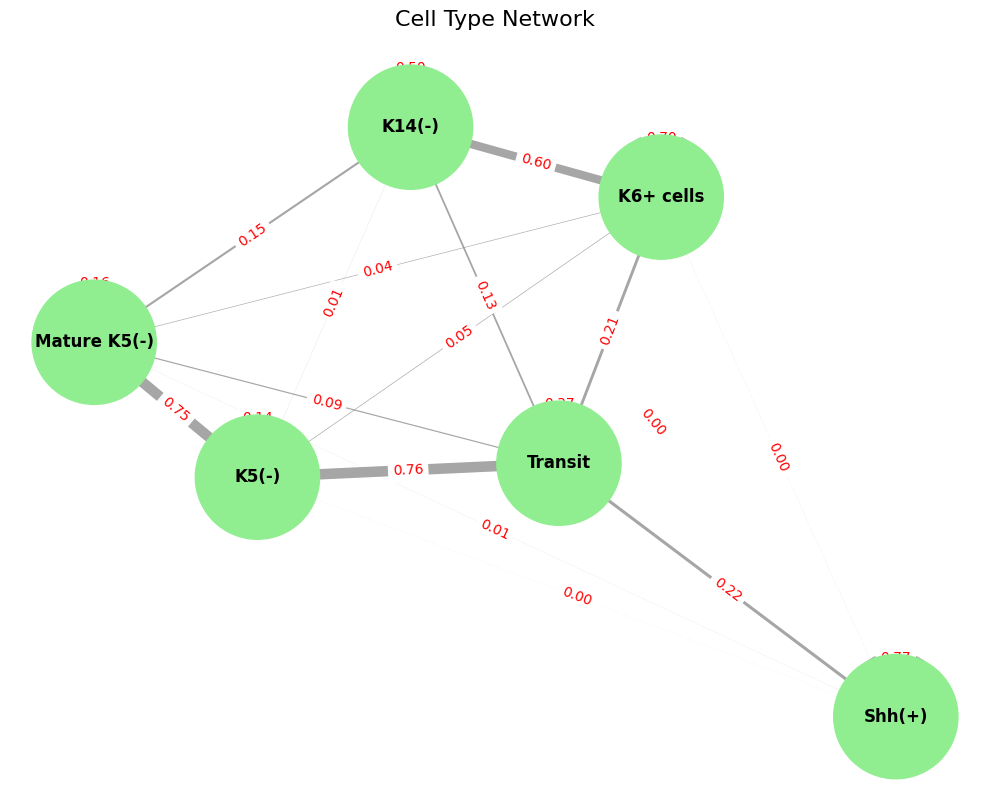

In [27]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Sample data including K14(-)
data = {
    "": ["Transit", "K5(-)", "Mature K5(-)", "Shh(+)", "K14(-)", "K6+ cells"],
    "Transit": [0.369848, 0.757051, 0.086197, 0.221353, 0.129112, 0.206645],
    "K5(-)": [0.349779, 0.137068, 0.747755, 0.002763, 0.008622, 0.046438],
    "Mature K5(-)": [0.221790, 0.026703, 0.159472, 0.005506, 0.151912, 0.043420],
    "Shh(+)": [0.046914, 0.067843, 0.000468, 0.770377, 0.001244, 0.000000],
    "K14(-)": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],  # Adjust as needed
    "K6+ cells": [0.011668, 0.011335, 0.006108, 0.004156, 0.709110, 0.703497]
}

# Convert to DataFrame
df = pd.DataFrame(data)
df.set_index("", inplace=True)

# Create a graph
G = nx.from_pandas_adjacency(df)

# Set node colors and sizes based on degree (number of connections)
node_color = ['lightblue' if degree < 3 else 'lightgreen' for node, degree in G.degree()]
node_size = [1000 * (G.degree(node) + 1) for node in G.nodes()]

# Set edge width based on weight
edge_width = [10 * G[u][v]['weight'] for u, v in G.edges()]

# Draw the network
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)  # Positions for all nodes
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
nx.draw_networkx_edges(G, pos, width=edge_width, edge_color='gray', alpha=0.7)

# Draw edge labels with weights
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_color='red')

plt.title("Cell Type Network", fontsize=16)
plt.axis('off')  # Hide the axes
plt.tight_layout()
plt.show()  # This will display the plot